<a href="https://colab.research.google.com/github/elisecolin/Tutorials_Notebooks/blob/main/BIOMASS_GEOREFERENCING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Search ESA BIOMASS Level-1A Single Look Complex (SLC) products from Google Colab

We query the MAAP STAC catalogue over the area of interest and
explicitly request science products containing the complex SAR
measurements (1S products, productType='S1_SCS__1S').

The 1M products only contain metadata and acquisition descriptors,
whereas the 1S products provide the actual radar signal, where SLC products contain amplitude and phase information from which
the complex radar observations can be reconstructed.

## ESA Authentication and MAAP Access Configuration

Before downloading BIOMASS products, you must authenticate against the ESA Multi-Mission Algorithm and Analysis Platform (MAAP). Access to BIOMASS datasets is restricted and requires a valid ESA account together with a personal offline access token.

### Step 1 — Create an ESA Earth Observation Account

If you do not already have an ESA account, first register on the ESA Earth Observation portal:

https://eoportal.esa.int

After registration:

1. Verify your email address.
2. Complete the account activation process.
3. Log in once to ensure the account is fully initialized.

This account will later be used to authenticate against the ESA MAAP services hosting the BIOMASS products.

---

### Step 2 — Generate an ESA MAAP Offline Token

The BIOMASS catalogue and download services use token-based authentication. Rather than repeatedly entering your credentials, ESA provides a long-lived *offline token* that can be used programmatically from Python scripts and Jupyter notebooks.

Open the ESA MAAP authentication service:

https://portal.maap.eo.esa.int/ini/services/auth/token/

Authenticate using your ESA account credentials.

After login, the platform generates a personal offline token.

The token typically looks like:

```text
eyJhbGciOi...
```

This token acts as a secure authentication credential that allows Python applications to access the MAAP APIs and download BIOMASS products without requiring interactive login.

---

### Step 3 — Store the Token Securely

Copy the generated token and store it in a secure location.

For example:

```python
OFFLINE_TOKEN = "eyJhbGciOi..."
```



In [1]:
!pip install -q pystac-client requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 7.0 MB/s eta 0:00:00


In [2]:
## Configure authentication

import requests
import numpy as np

# ============================================================
# PASTE YOUR OFFLINE TOKEN HERE
# ============================================================

OFFLINE_TOKEN = "PASTE YOUR OWN ONE HERE "

# ============================================================
# ESA MAAP OIDC CONFIGURATION
# ============================================================

CLIENT_ID = "offline-token"
CLIENT_SECRET = "p1eL7uonXs6MDxtGbgKdPVRAmnGxHpVE"
TOKEN_URL = (
    "https://iam.maap.eo.esa.int/"
    "realms/esa-maap/"
    "protocol/openid-connect/token"
)

# ============================================================
# REQUEST ACCESS TOKEN
# ============================================================

data = {
    "client_id": CLIENT_ID,
    "client_secret": CLIENT_SECRET,
    "grant_type": "refresh_token",
    "refresh_token": OFFLINE_TOKEN,
    "scope": "offline_access openid"
}

r = requests.post(TOKEN_URL, data=data)
print("HTTP:", r.status_code)
r.raise_for_status()
ACCESS_TOKEN = r.json()["access_token"]
print("ACCESS TOKEN OK")

HTTP: 200
ACCESS TOKEN OK


In [3]:
## Connect to ESA MAAP STAC

from pystac_client import Client

URL_LANDING_PAGE = "https://catalog.maap.eo.esa.int/catalogue/"
api = Client.open(URL_LANDING_PAGE)
print("Connected to MAAP STAC")

Connected to MAAP STAC


In [4]:
## Search for REAL BIOMASS SLC products


# ============================================================
# DEFINE FOOTPRINT
# ============================================================
bboxWGS84=[
    25.9590391,  # longitude West
    -28.2902569,   # latitude South
    26.4156371,  # longitude East
    -27.9962400    # latitude North
]

results = api.search(
    method='GET',
    collections='BiomassLevel1a',
    bbox=bboxWGS84,
    #datetime="2026-04-01/2026-05-31",
    filter=(
        "productType='S1_SCS__1S' "
        "or productType='S2_SCS__1S' "
        "or productType='S3_SCS__1S'"
    )
)
data = results.item_collection_as_dict()
n_found = len(data['features'])
print(f"{n_found} products found")

44 products found


In [5]:
# ============================================================
# PRINT PRODUCTS FOUND
# ============================================================
from shapely.geometry import shape
for n, feature in enumerate(data['features'], 1):
    product_name = feature['assets']['product']['file:local_path']
    print(
        f"{n:2d}. "
        f"{product_name}"
    )

 1. BIO_S3_SCS__1S_20260104T041951_20260104T042012_T_G01_M01_C01_T032_F286_01_DKQ54Y.ZIP
 2. BIO_S3_SCS__1S_20260107T042013_20260107T042034_T_G01_M01_C02_T032_F287_01_DKVT1R.ZIP
 3. BIO_S3_SCS__1S_20260110T041954_20260110T042015_T_G01_M01_C03_T032_F286_01_DL195R.ZIP
 4. BIO_S3_SCS__1S_20260110T042013_20260110T042034_T_G01_M01_C03_T032_F287_01_DL190K.ZIP
 5. BIO_S1_SCS__1S_20251123T041946_20251123T042006_T_G01_M01_C01_T032_F287_01_DNRUHC.ZIP
 6. BIO_S1_SCS__1S_20251123T041946_20251123T042007_T_G01_M01_C01_T032_F287_01_DK4OND.ZIP
 7. BIO_S1_SCS__1S_20251123T041927_20251123T041947_T_G01_M01_C01_T032_F286_01_DNHNO8.ZIP
 8. BIO_S1_SCS__1S_20251211T041938_20251211T041959_T_G01_M01_C07_T032_F286_01_DO9UFE.ZIP
 9. BIO_S1_SCS__1S_20251211T041957_20251211T042018_T_G01_M01_C07_T032_F287_01_DO9U7T.ZIP
10. BIO_S1_SCS__1S_20251202T041933_20251202T041953_T_G01_M01_C04_T032_F286_01_DKQZB0.ZIP
11. BIO_S1_SCS__1S_20251126T041929_20251126T041949_T_G01_M01_C02_T032_F286_01_DNVC6T.ZIP
12. BIO_S2_SCS__1S_20

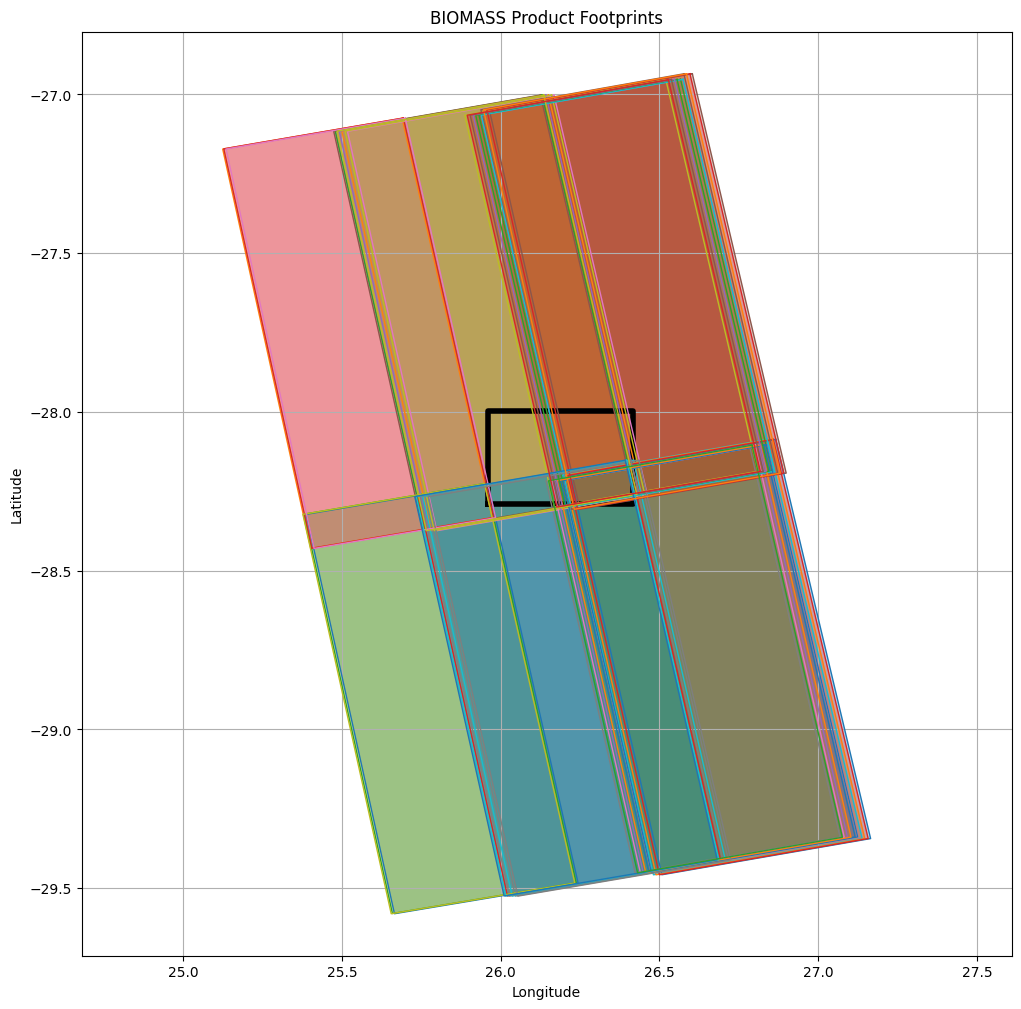

In [6]:
# ============================================================
# PLOT PRODUCT FOOTPRINTS
# ============================================================

from shapely.geometry import shape
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import re

fig, ax = plt.subplots(figsize=(12, 12))
# ------------------------------------------------------------------
# Query bbox (black, thick)
# ------------------------------------------------------------------

bbox_poly = Polygon([
    (bboxWGS84[0], bboxWGS84[1]),
    (bboxWGS84[2], bboxWGS84[1]),
    (bboxWGS84[2], bboxWGS84[3]),
    (bboxWGS84[0], bboxWGS84[3]),
    (bboxWGS84[0], bboxWGS84[1]),
])

x, y = bbox_poly.exterior.xy
ax.plot(
    x,
    y,
    color="black",
    linewidth=4,
    label="Query bbox"
)
# ------------------------------------------------------------------
# BIOMASS footprints
# ------------------------------------------------------------------
for feature in data["features"]:
    product = feature["assets"]["product"]["file:local_path"]
    m = re.search(r"_F(\d+)_", product)
    frame = m.group(1) if m else "?"
    geom = shape(feature["geometry"])
    x, y = geom.exterior.xy
    ax.fill(
        x,
        y,
        alpha=0.3
    )

    ax.plot(
        x,
        y,
        linewidth=1
    )
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("BIOMASS Product Footprints")
ax.grid(True)
ax.axis("equal")

plt.show()

In [7]:
# ============================================================
# SELECT THE PRODUCT YOU WANT TO DOWNLOAD
# ============================================================
# Here I select the product whose footprint provides the largest coverage
# of the requested bounding box.
# The index of the selected product is stored in best_idx.
# You can choose another one

from shapely.geometry import shape
best_idx = max(
    range(len(data["features"])),
    key=lambda i: (
        shape(data["features"][i]["geometry"])
        .intersection(bbox_poly)
        .area
        / bbox_poly.area
    )
)
print("Best index:", best_idx)
feature = data["features"][best_idx]

Best index: 16


# DOWNLOAD PRODUCT

In [8]:
# ============================================================
# DOWNLOAD REQUEST PRODUCT
# ============================================================

from pathlib import Path
import os

DOWNLOAD_DIR = Path("/content/biomass_slc")
DOWNLOAD_DIR.mkdir(exist_ok=True)
headers = {
    "Authorization": f"Bearer {ACCESS_TOKEN}"
}

feature = data['features'][best_idx]
file_url = feature['assets']['product']['href']
filename = feature['assets']['product']['file:local_path']
outpath = DOWNLOAD_DIR / filename

print("Downloading:")
print(file_url)

r = requests.get(
    file_url,
    headers=headers,
    stream=True
)

print("HTTP:", r.status_code)

r.raise_for_status()

with open(outpath, "wb") as f:
    for chunk in r.iter_content(chunk_size=8192):
        if chunk:
            f.write(chunk)
print("\nDOWNLOAD COMPLETE")
print(outpath)

Downloading:
https://catalog.maap.eo.esa.int/data/zipper/biomass-pdgs-01/BiomassLevel1a/2025/12/14/BIO_S2_SCS__1S_20251214T041958_20251214T042019_T_G01_M01_C01_T032_F287_01_DJMW9K/BIO_S2_SCS__1S_20251214T041958_20251214T042019_T_G01_M01_C01_T032_F287_01_DJMW9K
HTTP: 200

DOWNLOAD COMPLETE
/content/biomass_slc/BIO_S2_SCS__1S_20251214T041958_20251214T042019_T_G01_M01_C01_T032_F287_01_DJMW9K.ZIP


In [9]:
# ============================================================
# UNZIP PRODUCT
# ============================================================

import zipfile
from pathlib import Path
files = list(DOWNLOAD_DIR.glob("*"))
zip_files = list(DOWNLOAD_DIR.glob("*.ZIP"))
ZIP_PATH = zip_files[0]
EXTRACT_DIR = Path("/content/biomass_extracted")
EXTRACT_DIR.mkdir(exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)
print("Extracted to:")
print(EXTRACT_DIR)

Extracted to:
/content/biomass_extracted


# Data Exploration

In [10]:
tiff_files = list(EXTRACT_DIR.rglob("*.tiff"))
print(f"{len(tiff_files)} TIFF files found\n")
for f in tiff_files:
    print(f)
# At this step you should get 2 tiff files: one for the amplitudes, one for the phases


2 TIFF files found

/content/biomass_extracted/BIO_S2_SCS__1S_20251214T041958_20251214T042019_T_G01_M01_C01_T032_F287_01_DJMW9K/measurement/bio_s2_scs__1s_20251214t041958_20251214t042019_t_g01_m01_c01_t032_f287_i_abs.tiff
/content/biomass_extracted/BIO_S2_SCS__1S_20251214T041958_20251214T042019_T_G01_M01_C01_T032_F287_01_DJMW9K/measurement/bio_s2_scs__1s_20251214t041958_20251214t042019_t_g01_m01_c01_t032_f287_i_phase.tiff


In [11]:
# Reconstruct the complex SAR signal from amplitude and phase.
#
# BIOMASS SLC products store amplitude and phase separately.
# The complex radar measurement is recovered as:
#
#     S = A * exp(i * phi)
#
# where:
#     A     = amplitude
#     phi   = phase
#


amp_file = [
    f for f in tiff_files
    if "abs" in f.name.lower()
][0]

phase_file = [
    f for f in tiff_files
    if "phase" in f.name.lower()
][0]

print("AMPLITUDE:")
print(amp_file)

print("\nPHASE:")
print(phase_file)

AMPLITUDE:
/content/biomass_extracted/BIO_S2_SCS__1S_20251214T041958_20251214T042019_T_G01_M01_C01_T032_F287_01_DJMW9K/measurement/bio_s2_scs__1s_20251214t041958_20251214t042019_t_g01_m01_c01_t032_f287_i_abs.tiff

PHASE:
/content/biomass_extracted/BIO_S2_SCS__1S_20251214T041958_20251214T042019_T_G01_M01_C01_T032_F287_01_DJMW9K/measurement/bio_s2_scs__1s_20251214t041958_20251214t042019_t_g01_m01_c01_t032_f287_i_phase.tiff


In [12]:
import rasterio
with rasterio.open(amp_file) as src:

    amp_1 = src.read(1)
    amp_2 = src.read(2)
    amp_3 = src.read(3)
    amp_4 = src.read(4)

with rasterio.open(phase_file) as src:

    phase_1 = src.read(1)
    phase_2 = src.read(2)
    phase_3 = src.read(3)
    phase_4 = src.read(4)

print('Image Size: ', amp_1.shape)

Image Size:  (21190, 1568)


In [13]:
hh = amp_1 * np.exp(1j * phase_1)
hv = amp_2 * np.exp(1j * phase_2)
vh = amp_3 * np.exp(1j * phase_3)
vv = amp_4 * np.exp(1j * phase_4)

In [14]:
pauli_r = np.abs(vv - hh)
pauli_g = np.abs(hv + vh)
pauli_b = np.abs(vv + hh)

In [15]:
def stretch_percentile(img, p=98):
    vmax = np.nanpercentile(img, p)
    img = np.clip(img, 0, vmax)
    return img / vmax
r = stretch_percentile(pauli_r)
g = stretch_percentile(pauli_g)
b = stretch_percentile(pauli_b)

In [16]:
rgb = np.dstack([r, g, b])
rgb8 = np.clip(
    rgb * 255,
    0,
    255
).astype(np.uint8)


In [17]:
import rasterio
with rasterio.open(amp_file) as src:
    profile = src.profile.copy()
    profile.pop("nodata", None)
    profile.update(
        count=3,
        dtype="uint8",
        compress="deflate"
    )
    gcps, gcp_crs = src.gcps
    with rasterio.open(
        "biomass_pauli_radar.tif",
        "w",
        **profile
    ) as dst:
        dst.write(rgb8[:, :, 0], 1)
        dst.write(rgb8[:, :, 1], 2)
        dst.write(rgb8[:, :, 2], 3)
        dst.gcps = (gcps, gcp_crs)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:377: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


In [18]:
# Determination of the CRS
def get_display_crs_from_bbox(bbox):
    """
    bbox = [min_lon, min_lat, max_lon, max_lat]
    """
    lon_center = 0.5 * (bbox[0] + bbox[2])
    lat_center = 0.5 * (bbox[1] + bbox[3])
    # Antarctique
    if lat_center < -60:
        return "EPSG:3031"
    # Arctique
    if lat_center > 60:
        return "EPSG:3413"
    # UTM
    zone = int((lon_center + 180) / 6) + 1
    if lat_center >= 0:
        return f"EPSG:{32600 + zone}"
    else:
        return f"EPSG:{32700 + zone}"
dst_crs = get_display_crs_from_bbox(bboxWGS84)
print(dst_crs)


EPSG:32735


In [19]:
from rasterio.warp import calculate_default_transform
with rasterio.open("biomass_pauli_radar.tif") as src:
    gcps, gcp_crs = src.gcps
    transform, width, height = calculate_default_transform(
        src_crs=gcp_crs,
        dst_crs=dst_crs,
        width=src.width,
        height=src.height,
        gcps=gcps,
        resolution=10
    )

In [20]:
from rasterio.warp import reproject
from rasterio.enums import Resampling

with rasterio.open("biomass_pauli_radar.tif") as src:

    gcps, gcp_crs = src.gcps

    profile = src.profile.copy()

    profile.update(
        crs=dst_crs,
        transform=transform,
        width=width,
        height=height
    )

    with rasterio.open(
        "biomass_pauli_georef.tif",
        "w",
        **profile
    ) as dst:

        for band in range(1, 4):

            reproject(
                source=rasterio.band(src, band),
                destination=rasterio.band(dst, band),
                gcps=gcps,
                src_crs=gcp_crs,
                dst_crs=dst_crs,
                dst_transform=transform,
                resampling=Resampling.cubic
            )